# Used libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats

# Machine Learning 
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Machine Learning — Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print(" All libraries imported successfully!")

 All libraries imported successfully!


# --------------------------------------------------------------
## Stocks chosen for diversification:
## AAPL → Technology
## MSFT → Technology (more stable)
## JPM  → Banking (interest rate sensitive)
## XOM  → Energy (oil price driven)
# ---------------------------------------------------------------


In [2]:
tickers = ['AAPL', 'MSFT', 'JPM', 'XOM']

raw_data = yf.download(
    tickers,
    start='2015-01-01',
    end='2023-12-31',
    auto_adjust=True 
)

prices = raw_data['Close']

print(" Data downloaded successfully!")
print(f"Shape      : {prices.shape}")
print(f"Period     : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Stocks     : {list(prices.columns)}")
print(f"Missing    : {prices.isnull().sum().sum()}")
print()
print("Why 252 trading days per year?")
print("365 - 104 weekends - 9 holidays = ~252 days")
print()
print(prices.head(3).round(2))

[*********************100%***********************]  4 of 4 completed

 Data downloaded successfully!
Shape      : (2264, 4)
Period     : 2015-01-02 → 2023-12-29
Stocks     : ['AAPL', 'JPM', 'MSFT', 'XOM']
Missing    : 0

Why 252 trading days per year?
365 - 104 weekends - 9 holidays = ~252 days

Ticker       AAPL    JPM   MSFT    XOM
Date                                  
2015-01-02  24.21  46.51  39.77  57.53
2015-01-05  23.53  45.07  39.40  55.96
2015-01-06  23.53  43.90  38.82  55.66


# ---------------------------------------------------------------------------------------
# Why log returns and not simple returns?
. Additive over time (simple returns are not)
. More normally distributed
. Symmetric: +50% and -50% cancel correctly
. Formula: ln(Price_today / Price_yesterday)
# ----------------------------------------------------------------------------------------


In [3]:
print(raw_data.columns.tolist())

[('Close', 'AAPL'), ('Close', 'JPM'), ('Close', 'MSFT'), ('Close', 'XOM'), ('High', 'AAPL'), ('High', 'JPM'), ('High', 'MSFT'), ('High', 'XOM'), ('Low', 'AAPL'), ('Low', 'JPM'), ('Low', 'MSFT'), ('Low', 'XOM'), ('Open', 'AAPL'), ('Open', 'JPM'), ('Open', 'MSFT'), ('Open', 'XOM'), ('Volume', 'AAPL'), ('Volume', 'JPM'), ('Volume', 'MSFT'), ('Volume', 'XOM')]


In [4]:
log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna()

print(" Log Returns calculated!")
print(f"Shape: {log_returns.shape}")
print()
print("Return Statistics:")
print(log_returns.describe().round(4))
print()
print("Kurtosis per stock (Normal distribution = 3.0):")
print("Higher kurtosis = fatter tails = more extreme events")
for col in log_returns.columns:
    kurt = stats.kurtosis(log_returns[col])
    flag = " Fat tails!" if kurt > 5 else " Moderate"
    print(f"  {col}: {kurt:.2f}  {flag}")

 Log Returns calculated!
Shape: (2263, 4)

Return Statistics:
Ticker       AAPL        JPM       MSFT        XOM
count   2263.0000  2263.0000  2263.0000  2263.0000
mean       0.0009     0.0006     0.0010     0.0002
std        0.0183     0.0175     0.0175     0.0180
min       -0.1377    -0.1621    -0.1595    -0.1304
25%       -0.0075    -0.0074    -0.0069    -0.0085
50%        0.0009     0.0005     0.0010     0.0002
75%        0.0102     0.0087     0.0099     0.0088
max        0.1132     0.1656     0.1329     0.1194

Kurtosis per stock (Normal distribution = 3.0):
Higher kurtosis = fatter tails = more extreme events
  AAPL: 5.40   Fat tails!
  JPM: 13.34   Fat tails!
  MSFT: 7.98   Fat tails!
  XOM: 6.39   Fat tails!


# _____________________________________________________________________________________________
# Equal weight = 25% in each of 4 stocks
 Portfolio return = average of all 4 daily returns.
,axis=1 = average ACROSS columns (per day)
,axis=0 = average DOWN rows (per stock) — wrong!

# Diversification benefit:
 Portfolio worst day > any single stock worst day
 Because stocks don't all crash simultaneously
# ________________________________________________________________________________________________


In [5]:
portfolio_returns = log_returns.mean(axis=1)
portfolio_returns.name = 'portfolio_return'

print(" Portfolio constructed!")
print(f"Total trading days : {len(portfolio_returns)}")
print()
print("Portfolio Statistics:")
print(f"  Average daily return  : {portfolio_returns.mean():.4f}")
print(f"  Daily volatility      : {portfolio_returns.std():.4f}")
print(f"  Annualized return     : {portfolio_returns.mean()*252:.4f}")
print(f"  Best single day       : {portfolio_returns.max():.4f}")
print(f"  Worst single day      : {portfolio_returns.min():.4f}")
print(f"  Kurtosis              : {stats.kurtosis(portfolio_returns):.2f}")
print()
print("Compare worst days:")
print(f"  Worst individual stock: {log_returns.min().min():.4f}")
print(f"  Worst portfolio day   : {portfolio_returns.min():.4f}")
print(f"Portfolio less extreme = diversification working!")

 Portfolio constructed!
Total trading days : 2263

Portfolio Statistics:
  Average daily return  : 0.0007
  Daily volatility      : 0.0138
  Annualized return     : 0.1675
  Best single day       : 0.1092
  Worst single day      : -0.1398
  Kurtosis              : 12.49

Compare worst days:
  Worst individual stock: -0.1621
  Worst portfolio day   : -0.1398
Portfolio less extreme = diversification working!


# _________________________________________________________________________________________________________________
#  VALUE AT RISK (VaR)

 VaR answers: "What is my worst expected loss
              on a bad day?"

 Historical VaR at 5% confidence:
 → Look at last 252 days of returns
 → Find the 5th percentile (worst 5%)
 → That is today's danger threshold
#
 Rolling window (not fixed) because:
→ Risk levels change over time
 → 2020 COVID VaR ≠ 2017 calm market VaR
 → Model must adapt to current conditions
# ____________________________________________________________________________________________________________________



In [6]:
rolling_var = portfolio_returns.rolling(
    window=252
).quantile(0.05)
rolling_var.name = 'VaR_5pct'

# Drop warmup period
# First 252 days have no rolling history yet
var_clean     = rolling_var.dropna()
returns_clean = portfolio_returns.loc[var_clean.index]

print(" Rolling VaR calculated!")
print(f"Warmup period    : First 252 days dropped")
print(f"VaR starts from  : {var_clean.index[0].date()}")
print(f"Days with VaR    : {len(var_clean)}")
print()
print("VaR Statistics:")
print(f"  Average VaR threshold : {var_clean.mean():.4f} ({var_clean.mean():.2%})")
print(f"  Most severe VaR ever  : {var_clean.min():.4f} ({var_clean.min():.2%})")
print(f"  Calmest VaR ever      : {var_clean.max():.4f} ({var_clean.max():.2%})")
print()
print("Plain English:")
print(f"  On a typical bad day portfolio loses {abs(var_clean.mean()):.2%}")
print(f"  On ₹1,00,000 investment = ₹{abs(var_clean.mean())*100000:.0f} loss")
print(f"  During COVID worst case = {abs(var_clean.min()):.2%} loss")

 Rolling VaR calculated!
Warmup period    : First 252 days dropped
VaR starts from  : 2016-01-04
Days with VaR    : 2012

VaR Statistics:
  Average VaR threshold : -0.0204 (-2.04%)
  Most severe VaR ever  : -0.0411 (-4.11%)
  Calmest VaR ever      : -0.0077 (-0.77%)

Plain English:
  On a typical bad day portfolio loses 2.04%
  On ₹1,00,000 investment = ₹2036 loss
  During COVID worst case = 4.11% loss


# ════════════════════════════════════════════════
# CREATE TARGET VARIABLES (LABELS)
# ════════════════════════════════════════════════
 These are what our ML models learn to predict

 TASK 1 — Return Direction:
  1 = portfolio went UP today
  0 = portfolio went DOWN today

 TASK 2 — VaR Breach:
   1 = loss exceeded VaR threshold (DANGER!)
   0 = normal day, loss within acceptable range

 VaR breach condition:
   Both return and VaR are negative numbers
   Breach = return < VaR (more negative than threshold)
   Example: return=-3% < VaR=-2% → BREACH


In [7]:
return_label = (returns_clean > 0).astype(int)
return_label.name = 'return_label'

var_breach_label = (returns_clean < var_clean).astype(int)
var_breach_label.name = 'var_breach_label'

print(" Labels created!")
print()
print("TASK 1 — Return Direction:")
print(f"  UP days   (1): {return_label.sum()}"
      f" ({return_label.mean():.1%})")
print(f"  DOWN days (0): {(return_label==0).sum()}"
      f" ({(return_label==0).mean():.1%})")
print(f"  → Slightly more up days = markets trend upward")

print()
print("TASK 2 — VaR Breach:")
print(f"  Safe days    (0): {(var_breach_label==0).sum()}"
      f" ({(var_breach_label==0).mean():.1%})")
print(f"  Breach days  (1): {var_breach_label.sum()}"
      f" ({var_breach_label.mean():.1%})")

print()
print("  CRITICAL BASELINE TO BEAT:")
baseline = (var_breach_label==0).mean()
print(f"  Dumb model (always predict safe) accuracy = {baseline:.2%}")
print(f"  Our models MUST beat this using F1 and AUC")
print(f"  Accuracy alone is MISLEADING for Task 2!")

 Labels created!

TASK 1 — Return Direction:
  UP days   (1): 1089 (54.1%)
  DOWN days (0): 923 (45.9%)
  → Slightly more up days = markets trend upward

TASK 2 — VaR Breach:
  Safe days    (0): 1909 (94.9%)
  Breach days  (1): 103 (5.1%)

  CRITICAL BASELINE TO BEAT:
  Dumb model (always predict safe) accuracy = 94.88%
  Our models MUST beat this using F1 and AUC
  Accuracy alone is MISLEADING for Task 2!


# ════════════════════════════════════════════════
#  FEATURE ENGINEERING
# ════════════════════════════════════════════════
 Features = signals the model learns from
 Each feature has a financial reason to exist

 GOLDEN RULE: Every feature uses .shift(1)
 → We predict TODAY using YESTERDAY's data
 → Using today's data = data leakage = cheating
 → Model would fail completely in real trading

## Features and their financial meaning:
#### return_lag 1,2,3 → short term momentum/reversal
#### vol_5d,20d      → volatility clustering (risk regime)
#### mean_5d,20d     → trend direction
#### momentum_10d    → medium term market direction

In [8]:
features = pd.DataFrame(index=returns_clean.index)

# Lag Returns
features['return_lag1']  = returns_clean.shift(1)
features['return_lag2']  = returns_clean.shift(2)
features['return_lag3']  = returns_clean.shift(3)

# Rolling Volatility
features['vol_5d']       = returns_clean.rolling(5).std().shift(1)
features['vol_20d']      = returns_clean.rolling(20).std().shift(1)

# Rolling Mean Return
features['mean_5d']      = returns_clean.rolling(5).mean().shift(1)
features['mean_20d']     = returns_clean.rolling(20).mean().shift(1)

# Momentum
features['momentum_10d'] = returns_clean.rolling(10).sum().shift(1)

# Drop NaN rows
features = features.dropna()

# Align all data
common_idx = features.index
X          = features.loc[common_idx]
y_return   = return_label.loc[common_idx]
y_var      = var_breach_label.loc[common_idx]

print(" Features engineered!")
print(f"Dataset shape : {X.shape}")
print(f"Features      : {list(X.columns)}")
print(f"NaN values    : {X.isnull().sum().sum()}")
print()

# Key signal check
vol_breach = X.loc[y_var==1, 'vol_5d'].mean()
vol_normal = X.loc[y_var==0, 'vol_5d'].mean()
print("Signal Check — Can model learn something?")
print(f"  Avg vol on BREACH days : {vol_breach:.4f}")
print(f"  Avg vol on NORMAL days : {vol_normal:.4f}")
print(f"  Ratio                  : {vol_breach/vol_normal:.1f}x higher")
print(f"  → YES! Model has a real signal to learn from")

 Features engineered!
Dataset shape : (1992, 8)
Features      : ['return_lag1', 'return_lag2', 'return_lag3', 'vol_5d', 'vol_20d', 'mean_5d', 'mean_20d', 'momentum_10d']
NaN values    : 0

Signal Check — Can model learn something?
  Avg vol on BREACH days : 0.0191
  Avg vol on NORMAL days : 0.0107
  Ratio                  : 1.8x higher
  → YES! Model has a real signal to learn from


# ════════════════════════════════════════════════
# DATA VISUALIZATION
# ════════════════════════════════════════════════



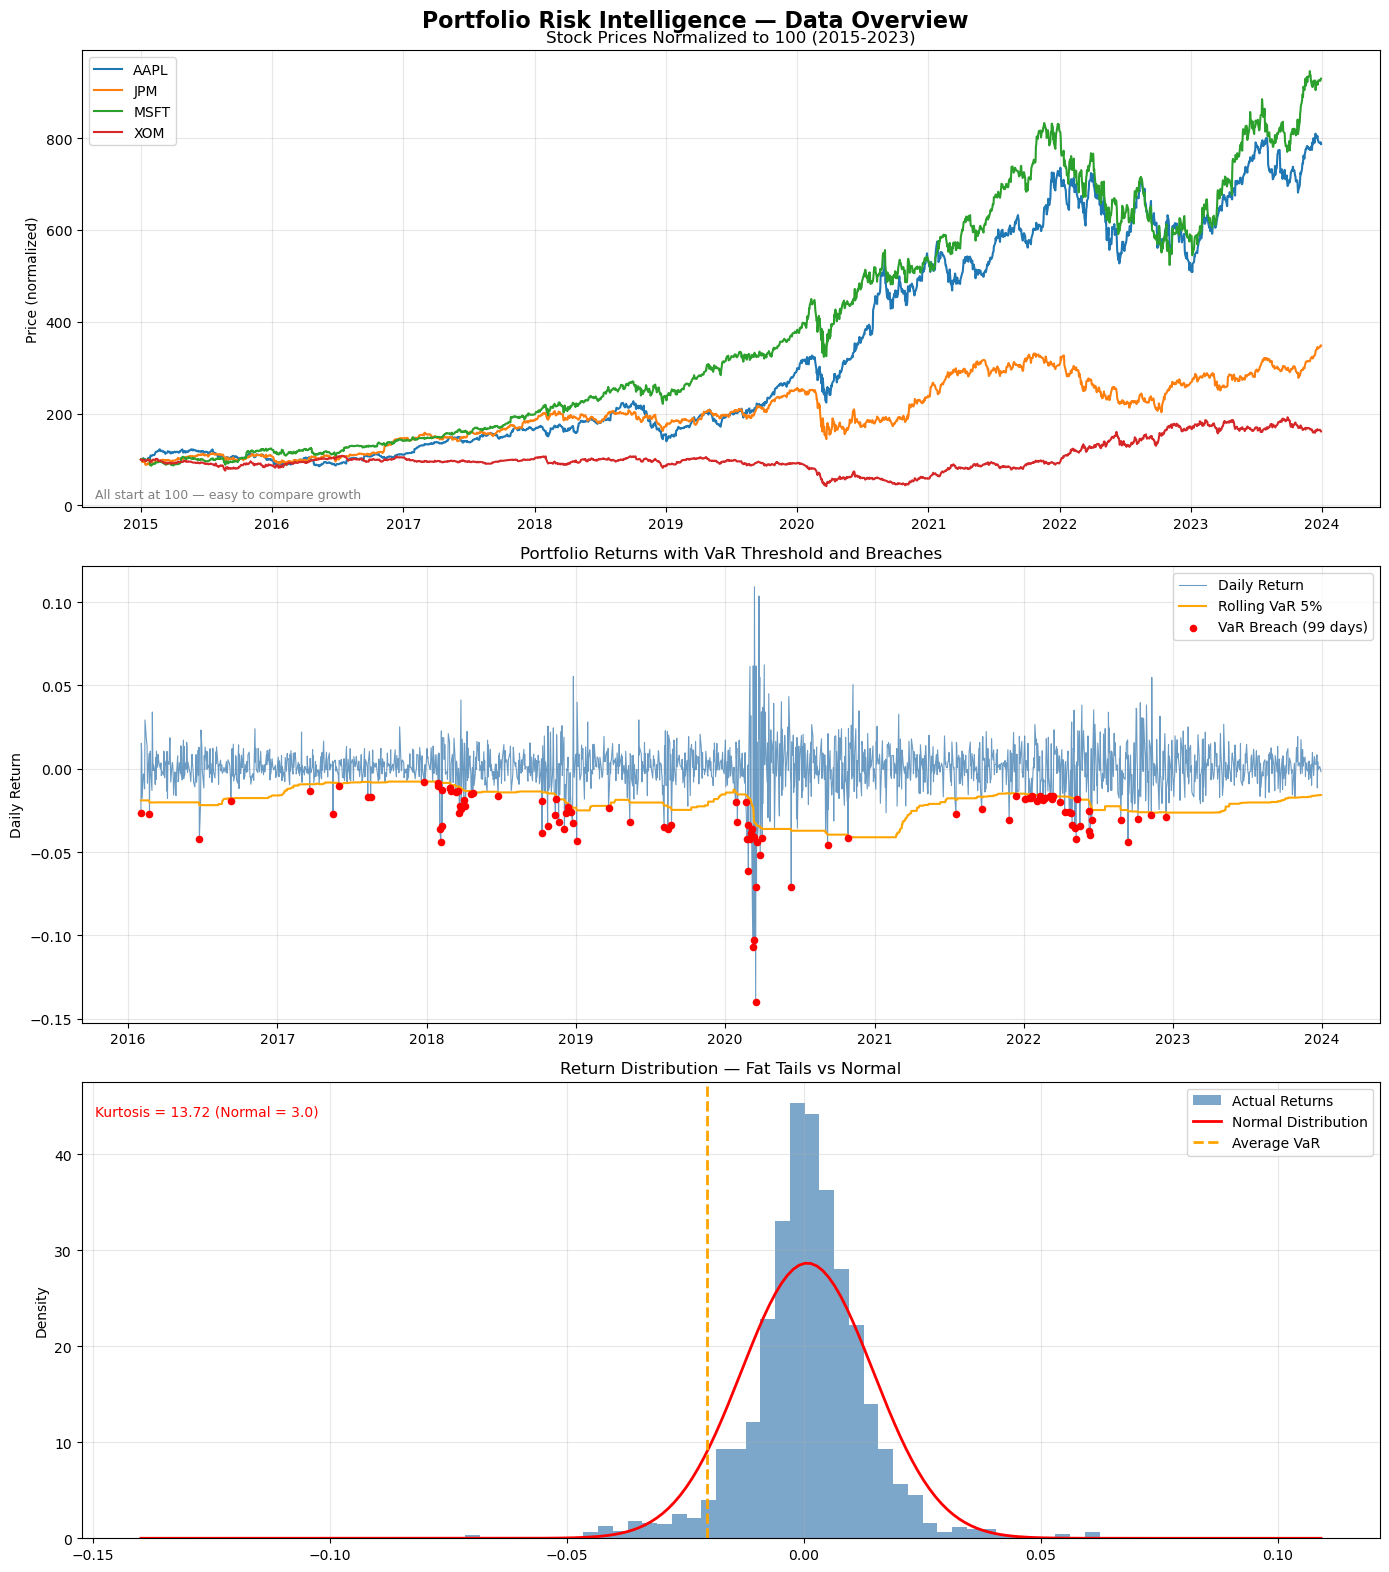

Charts plotted!


In [9]:
# Fix index alignment first
returns_aligned = returns_clean.loc[y_var.index]
var_aligned     = var_clean.loc[y_var.index]

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle('Portfolio Risk Intelligence — Data Overview',
             fontsize=16, fontweight='bold')

# ── Chart 1: Normalized Stock Prices ─────────────────────
ax1 = axes[0]
for ticker in prices.columns:
    norm = prices[ticker] / prices[ticker].iloc[0] * 100
    ax1.plot(norm.index, norm,
             linewidth=1.5, label=ticker)
ax1.set_title('Stock Prices Normalized to 100 (2015-2023)',
              fontsize=12)
ax1.set_ylabel('Price (normalized)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.01, 0.02,
         'All start at 100 — easy to compare growth',
         transform=ax1.transAxes,
         fontsize=9, color='gray')

# ── Chart 2: Returns + VaR + Breaches ────────────────────
ax2 = axes[1]
ax2.plot(returns_aligned.index, returns_aligned,
         color='steelblue', linewidth=0.8,
         alpha=0.8, label='Daily Return')
ax2.plot(var_aligned.index, var_aligned,
         color='orange', linewidth=1.5,
         label='Rolling VaR 5%')

# Fix: use aligned series for breach detection
breach_mask  = y_var == 1
breach_dates = returns_aligned[breach_mask]
ax2.scatter(breach_dates.index, breach_dates.values,
            color='red', s=20, zorder=5,
            label=f'VaR Breach ({breach_mask.sum()} days)')
ax2.set_title('Portfolio Returns with VaR Threshold and Breaches',
              fontsize=12)
ax2.set_ylabel('Daily Return')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── Chart 3: Return Distribution ─────────────────────────
ax3 = axes[2]
ax3.hist(returns_aligned, bins=80, density=True,
         color='steelblue', alpha=0.7,
         label='Actual Returns')
x_range = np.linspace(returns_aligned.min(),
                      returns_aligned.max(), 200)
normal_curve = stats.norm.pdf(
    x_range,
    returns_aligned.mean(),
    returns_aligned.std()
)
ax3.plot(x_range, normal_curve,
         color='red', linewidth=2,
         label='Normal Distribution')
ax3.axvline(var_aligned.mean(),
            color='orange', linewidth=2,
            linestyle='--', label='Average VaR')
ax3.set_title('Return Distribution — Fat Tails vs Normal',
              fontsize=12)
ax3.set_ylabel('Density')
ax3.legend()
ax3.grid(True, alpha=0.3)
kurtosis_val = stats.kurtosis(returns_aligned)
ax3.text(0.01, 0.95,
         f'Kurtosis = {kurtosis_val:.2f} (Normal = 3.0)',
         transform=ax3.transAxes,
         fontsize=10, color='red',
         verticalalignment='top')

plt.tight_layout()
plt.show()
print("Charts plotted!")

# ════════════════════════════════════════════════
#  TRAIN TEST SPLIT AND FEATURE SCALING
# ════════════════════════════════════════════════
### WHY CHRONOLOGICAL SPLIT (not random)?
 → Random split leaks future into past (cheating)
 → Chronological split mirrors real trading
 → Train on past, predict future = honest

### WHY SCALE FEATURES?
 → vol_5d ranges 0.001 to 0.10
 → momentum_10d ranges -0.30 to +0.18
 → Different scales confuse the model
 → After scaling: every feature mean=0, std=1
 → Formula: scaled = (value - mean) / std

 GOLDEN RULE: Fit scaler on TRAIN only!
 → Fitting on all data leaks test statistics
 → Test set must remain completely unseen





In [10]:

# ── Train Test Split ──────────────────────────────────────
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train_return = y_return.iloc[:split_index]
y_test_return  = y_return.iloc[split_index:]

y_train_var    = y_var.iloc[:split_index]
y_test_var     = y_var.iloc[split_index:]

print(" Train Test Split Done!")
print(f"Training: {len(X_train)} days"
      f" ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Testing : {len(X_test)} days"
      f" ({X_test.index[0].date()} → {X_test.index[-1].date()})")
print()

# ── Feature Scaling ───────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_train)    # fit ONLY on training data

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print(" Features Scaled!")
print(f"Before: vol_5d mean={X_train['vol_5d'].mean():.4f},"
      f" std={X_train['vol_5d'].std():.4f}")
print(f"After : vol_5d mean={X_train_scaled['vol_5d'].mean():.4f},"
      f" std={X_train_scaled['vol_5d'].std():.4f}")
print()
print("All features now have mean≈0, std≈1")

 Train Test Split Done!
Training: 1593 days (2016-02-02 → 2022-05-27)
Testing : 399 days (2022-05-31 → 2023-12-29)

 Features Scaled!
Before: vol_5d mean=0.0110, std=0.0097
After : vol_5d mean=-0.0000, std=1.0003

All features now have mean≈0, std≈1


# ════════════════════════════════════════════════
### HELPER FUNCTION — EVALUATE ANY MODEL
# ════════════════════════════════════════════════
 We will reuse this for all 3 algorithms
 Calculates all metrics in one clean function


In [11]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """
    Evaluate a binary classifier and print all metrics.
    Returns: [accuracy, precision, recall, f1, auc]
    """
    acc  = accuracy_score(y_true,  y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true,    y_pred, zero_division=0)
    f1   = f1_score(y_true,        y_pred, zero_division=0)
    auc  = roc_auc_score(y_true,   y_prob)

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}"
          f"  ← {'Misleading here!' if 'VaR' in name else 'Overall correct %'}")
    print(f"  Precision : {prec:.4f}"
          f"  ← Of predicted positives, how many were real")
    print(f"  Recall    : {rec:.4f}"
          f"  ← Of actual positives, how many did we catch")
    print(f"  F1 Score  : {f1:.4f}"
          f"  ← Balance of precision and recall")
    print(f"  ROC AUC   : {auc:.4f}"
          f"  ← 0.5=random, 1.0=perfect")
    print()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"  Confusion Matrix:")
    print(f"    True Negatives  (correctly safe)   : {tn}")
    print(f"    False Positives (wrong alarm)       : {fp}")
    print(f"    False Negatives (missed danger!)    : {fn}")
    print(f"    True Positives  (caught danger!)    : {tp}")

    if 'VaR' in name:
        total = y_true.sum()
        print(f"\n  Breach Detection: caught {tp}/{total}")

    print()
    return [acc, prec, rec, f1, auc]


# Storage for comparison table
all_results = {}

print("Helper function ready!")
print("Will be used for all 3 algorithms")

Helper function ready!
Will be used for all 3 algorithms


# ║          LOGISTIC REGRESSION      ║
 
  Simplest algorithm — our baseline          
   Assumes linear relationship between        
  features and target                         
                                             
   How it works:                             
 1. Compute weighted sum of features         
      z = w1*vol + w2*momentum + ...           
  2. Squeeze through sigmoid function
  3.       P = 1 / (1 + e^(-z))                     
  4. Output probability 0 to 1                
  5. P > 0.5 → predict class 1                
                                               
  Key parameter:                              
   C = regularization (high C = less regular.) 
 

In [12]:

# Task 1: Return Direction
lr_return = LogisticRegression(
    C=1.0,              # regularization strength
    class_weight='balanced',  # fix class imbalance
    max_iter=1000,      # training iterations
    random_state=42
)
lr_return.fit(X_train_scaled, y_train_return)

# Task 2: VaR Breach
lr_var = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_var.fit(X_train_scaled, y_train_var)

print(" Logistic Regression trained!")
print()

# Show coefficients — what model learned
print("What model learned (coefficients):")
print()
print("TASK 1 — Return Direction:")
print("Positive = increases UP probability")
print("Negative = increases DOWN probability")
coef_return = pd.Series(
    lr_return.coef_[0],
    index=X.columns
).sort_values(ascending=False)

for feat, coef in coef_return.items():
    bar = "" * int(abs(coef) * 20)
    sign = "+" if coef > 0 else "-"
    print(f"  {feat:15s} {sign}{bar} {coef:.4f}")

print()
print("TASK 2 — VaR Breach:")
print("Positive = increases breach probability")
coef_var = pd.Series(
    lr_var.coef_[0],
    index=X.columns
).sort_values(ascending=False)

for feat, coef in coef_var.items():
    bar = "" * int(abs(coef) * 20)
    sign = "+" if coef > 0 else "-"
    print(f"  {feat:15s} {sign}{bar} {coef:.4f}")

 Logistic Regression trained!

What model learned (coefficients):

TASK 1 — Return Direction:
Positive = increases UP probability
Negative = increases DOWN probability
  return_lag2     + 0.0600
  vol_5d          + 0.0488
  mean_20d        + 0.0297
  momentum_10d    + 0.0263
  return_lag3     + 0.0251
  vol_20d         - -0.0309
  return_lag1     - -0.1086
  mean_5d         - -0.1285

TASK 2 — VaR Breach:
Positive = increases breach probability
  vol_5d          + 0.2271
  vol_20d         + 0.0742
  return_lag3     + 0.0269
  return_lag1     - -0.0048
  mean_5d         - -0.0087
  return_lag2     - -0.1106
  momentum_10d    - -0.1425
  mean_20d        - -0.4047


  LOGISTIC REGRESSION — Task 1 Return Direction
  Accuracy  : 0.4937  ← Overall correct %
  Precision : 0.5097  ← Of predicted positives, how many were real
  Recall    : 0.5097  ← Of actual positives, how many did we catch
  F1 Score  : 0.5097  ← Balance of precision and recall
  ROC AUC   : 0.4784  ← 0.5=random, 1.0=perfect

  Confusion Matrix:
    True Negatives  (correctly safe)   : 92
    False Positives (wrong alarm)       : 101
    False Negatives (missed danger!)    : 101
    True Positives  (caught danger!)    : 105

  LOGISTIC REGRESSION — Task 2 VaR Breach
  Accuracy  : 0.6817  ← Misleading here!
  Precision : 0.0317  ← Of predicted positives, how many were real
  Recall    : 0.4444  ← Of actual positives, how many did we catch
  F1 Score  : 0.0593  ← Balance of precision and recall
  ROC AUC   : 0.5875  ← 0.5=random, 1.0=perfect

  Confusion Matrix:
    True Negatives  (correctly safe)   : 268
    False Positives (wrong alarm)       : 122
    False Negatives (missed danger!

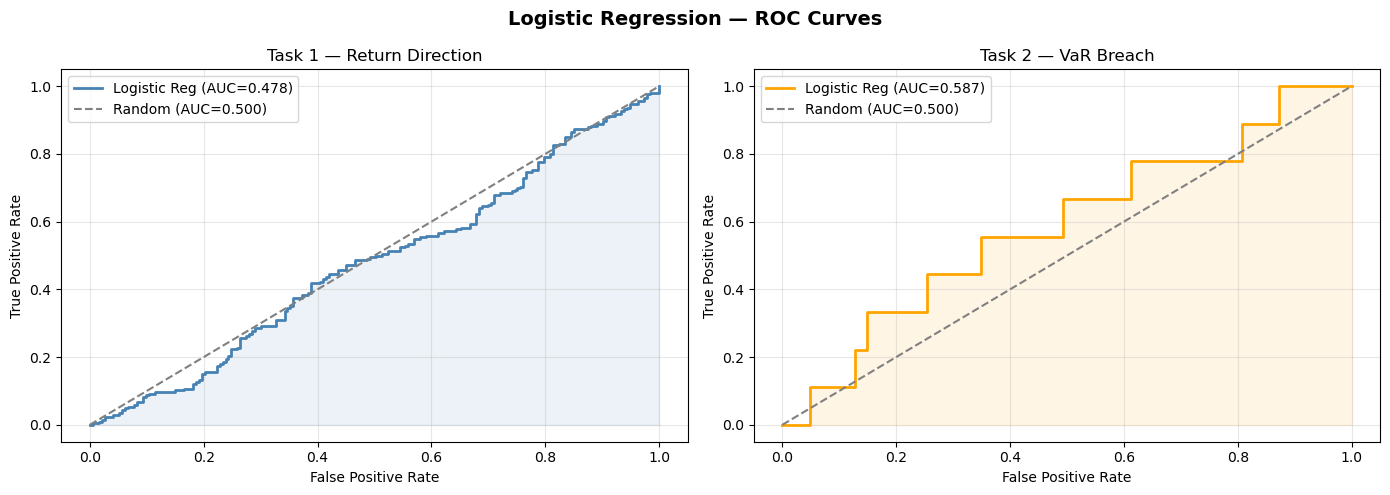

Key Findings — Logistic Regression:
  Task 1 AUC = 0.4784 → near random (markets are efficient)
  Task 2 AUC = 0.5875 → slightly above random
  Task 2 F1  = 0.0593 → class imbalance problem


In [13]:
# ════════════════════════════════════════════════
# LOGISTIC REGRESSION — EVALUATION
# ════════════════════════════════════════════════

# Predictions
y_pred_lr_return = lr_return.predict(X_test_scaled)
y_prob_lr_return = lr_return.predict_proba(X_test_scaled)[:,1]

y_pred_lr_var    = lr_var.predict(X_test_scaled)
y_prob_lr_var    = lr_var.predict_proba(X_test_scaled)[:,1]

# Evaluate
lr_t1 = evaluate_model(
    "LOGISTIC REGRESSION — Task 1 Return Direction",
    y_test_return, y_pred_lr_return, y_prob_lr_return
)
lr_t2 = evaluate_model(
    "LOGISTIC REGRESSION — Task 2 VaR Breach",
    y_test_var, y_pred_lr_var, y_prob_lr_var
)

# Store results
all_results['Logistic Regression'] = {
    'T1': lr_t1, 'T2': lr_t2
}

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — ROC Curves',
             fontsize=14, fontweight='bold')

for ax, y_true, y_prob, title, color in zip(
    axes,
    [y_test_return, y_test_var],
    [y_prob_lr_return, y_prob_lr_var],
    ['Task 1 — Return Direction',
     'Task 2 — VaR Breach'],
    ['steelblue', 'orange']
):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'Logistic Reg (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'--', color='gray',
            label='Random (AUC=0.500)')
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Findings — Logistic Regression:")
print(f"  Task 1 AUC = {lr_t1[4]:.4f} → near random"
      f" (markets are efficient)")
print(f"  Task 2 AUC = {lr_t2[4]:.4f} → slightly above random")
print(f"  Task 2 F1  = {lr_t2[3]:.4f} → class imbalance problem")

 # -----------------------DECISION TREE-----------------------------    

  Rule-based algorithm — most interpretable   
  Learns IF-THEN rules from data              
                                              
 How it works:                               
 1. Find best feature + threshold to split   
 2. Measure split quality using Gini impurity
     Gini = 1 - (p_class1² + p_class2²)      
 3. Repeat on each branch recursively        
  4. Stop at max_depth or pure nodes          
                                              
  Key parameters:                             
  max_depth = controls overfitting            
  class_weight = fixes class imbalance        
                                              
 Improvement over LR:                        
→ Captures non-linear relationships         
→ IF vol_high AND momentum_negative → BREACH
→ LR cannot learn such interactions        


 Decision Trees trained!
Tree depth     : 4
Number of leaves: 14



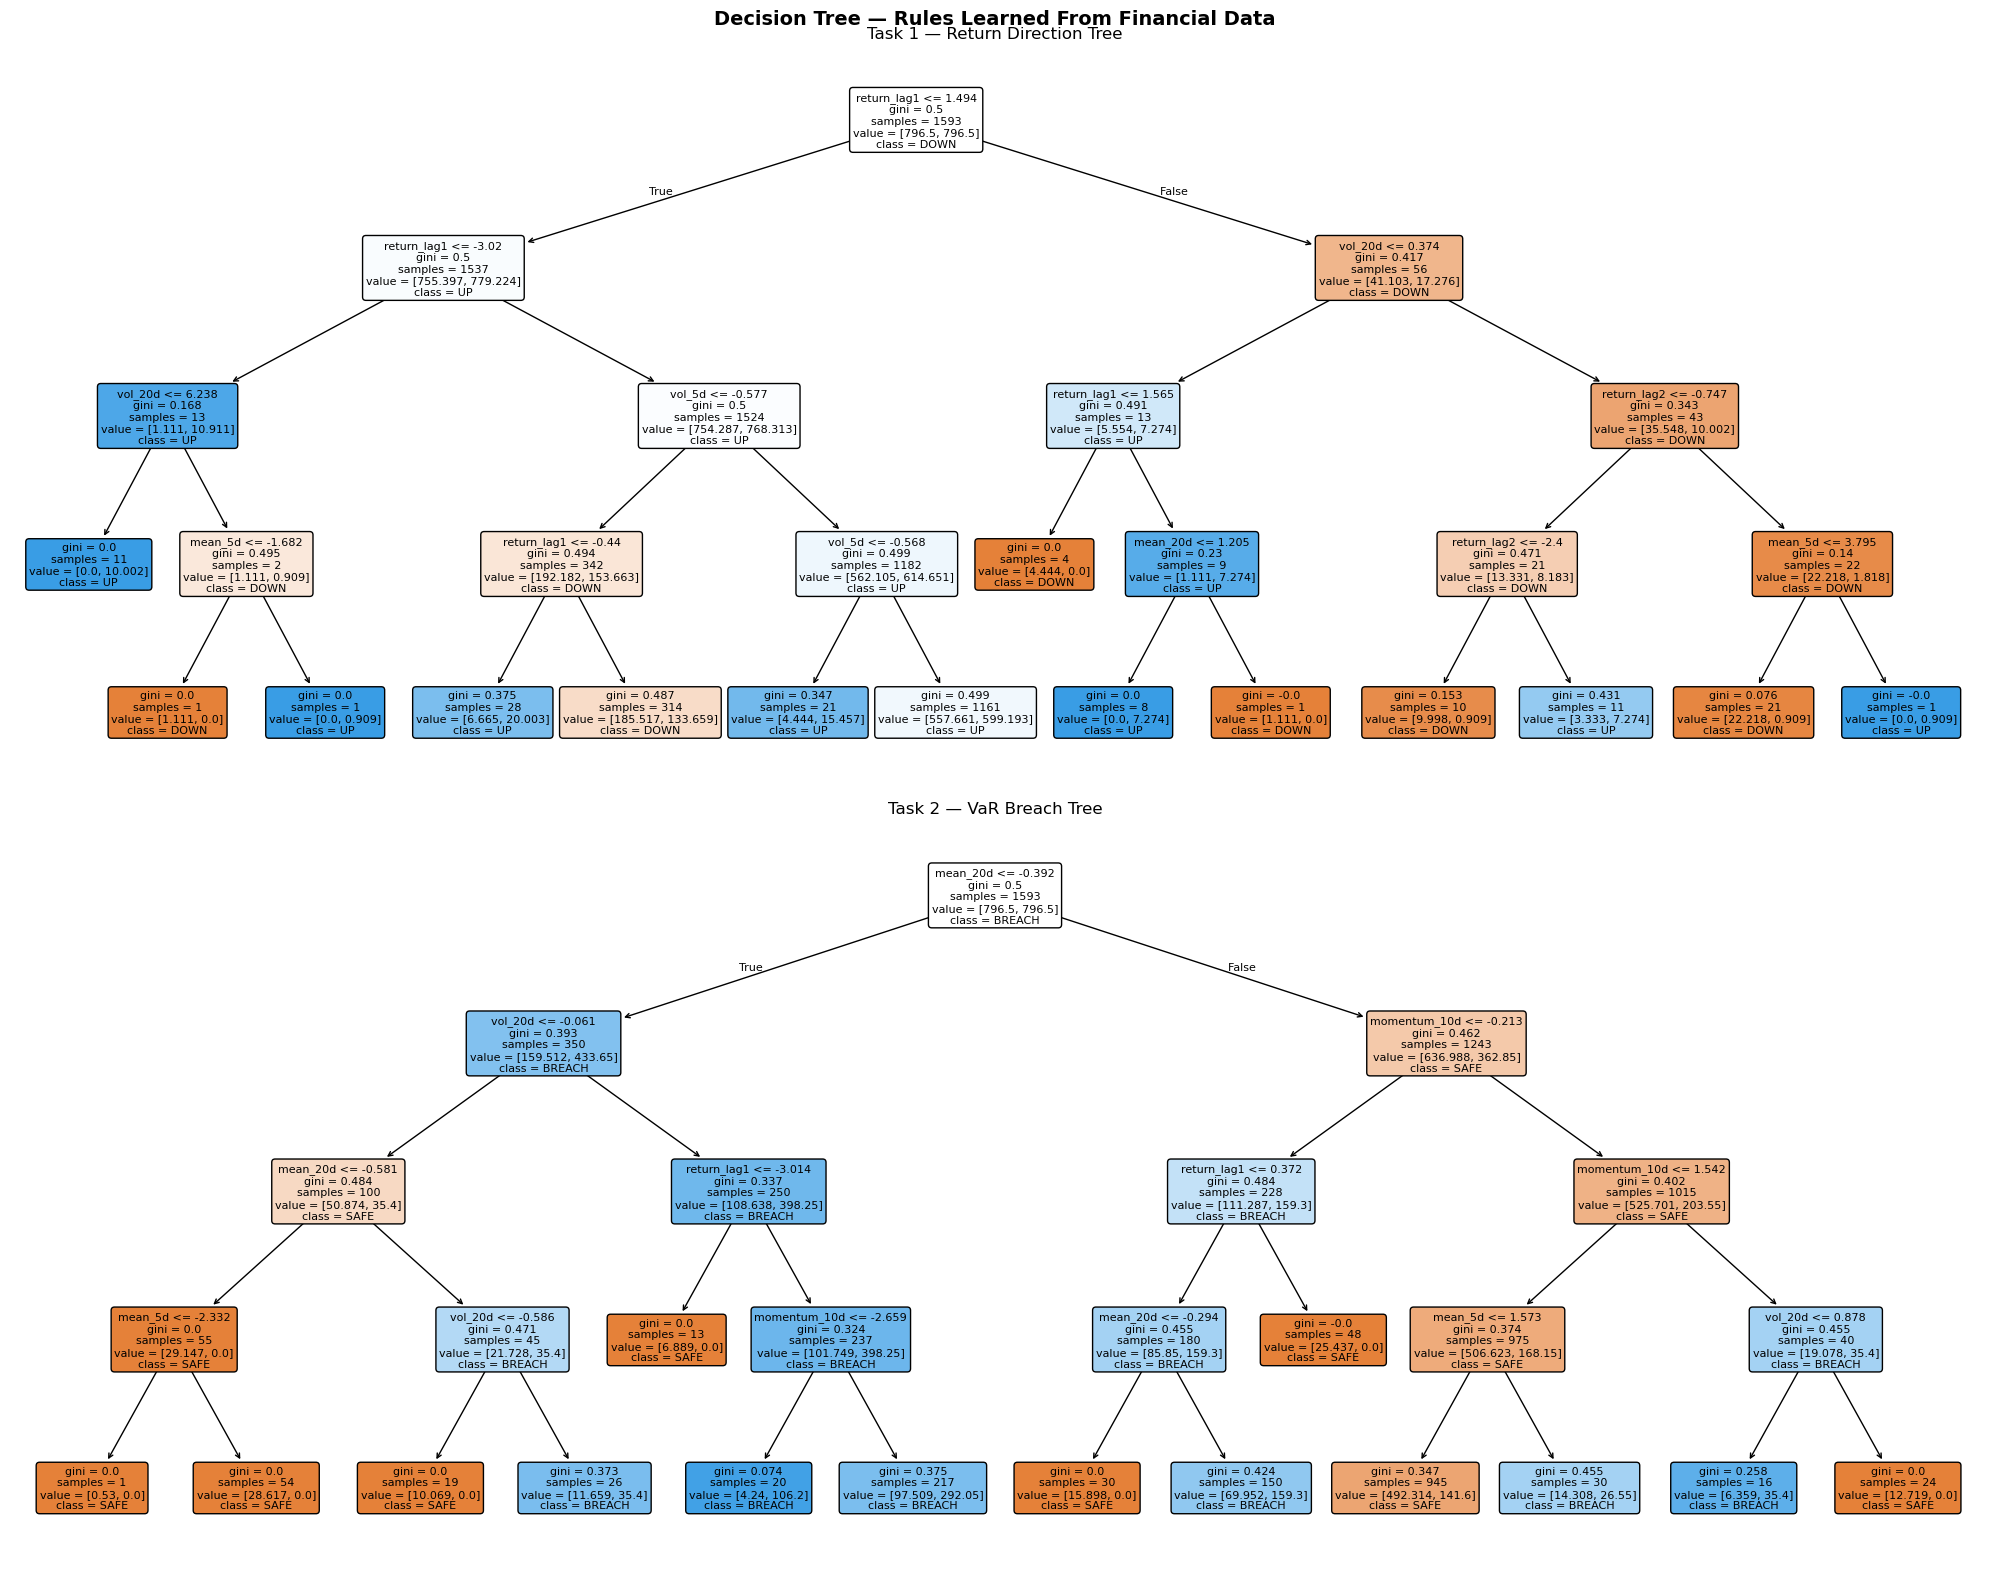

Read the tree from top to bottom
Each node = one IF-THEN rule
Colors = predicted class (darker = more confident)


In [14]:
# ════════════════════════════════════════════════
# DECISION TREE — TRAINING
# ════════════════════════════════════════════════

# Task 1: Return Direction
dt_return = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)
dt_return.fit(X_train_scaled, y_train_return)

# Task 2: VaR Breach
dt_var = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)
dt_var.fit(X_train_scaled, y_train_var)

print(" Decision Trees trained!")
print(f"Tree depth     : {dt_return.get_depth()}")
print(f"Number of leaves: {dt_return.get_n_leaves()}")
print()

# Visualize trees
fig, axes = plt.subplots(2, 1, figsize=(20, 16))
fig.suptitle('Decision Tree — Rules Learned From Financial Data',
             fontsize=14, fontweight='bold')

plot_tree(dt_return,
          feature_names=X.columns.tolist(),
          class_names=['DOWN', 'UP'],
          filled=True, rounded=True,
          fontsize=8, ax=axes[0])
axes[0].set_title('Task 1 — Return Direction Tree')

plot_tree(dt_var,
          feature_names=X.columns.tolist(),
          class_names=['SAFE', 'BREACH'],
          filled=True, rounded=True,
          fontsize=8, ax=axes[1])
axes[1].set_title('Task 2 — VaR Breach Tree')

plt.tight_layout()
plt.show()
print("Read the tree from top to bottom")
print("Each node = one IF-THEN rule")
print("Colors = predicted class (darker = more confident)")

# ════════════════════════════════════════════════
## DECISION TREE — OVERFITTING ANALYSIS
# ════════════════════════════════════════════════
Most important lesson in all of ML:

 Shallow tree (depth=1-3):
 → Misses complex patterns → UNDERFITTING

 Right depth (depth=4-6):
 → Learns real patterns → BALANCED 

 Deep tree (depth=15+):
 → Memorizes training data → OVERFITTING
 → Fails completely on new data



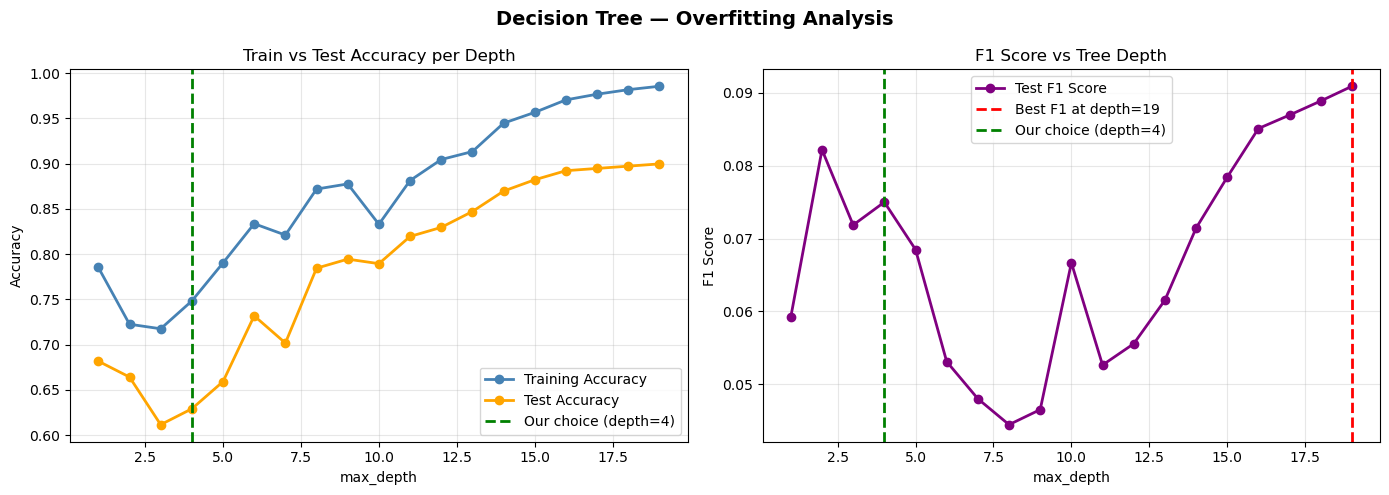

Best F1 depth = 19

Reading the gap between blue and orange lines:
  Small gap = healthy, balanced model
  Large gap = overfitting, model memorizing


In [15]:
train_scores = []
test_scores  = []
f1_test      = []
depths       = range(1, 20)

for depth in depths:
    dt_temp = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )
    dt_temp.fit(X_train_scaled, y_train_var)
    y_temp_pred = dt_temp.predict(X_test_scaled)

    train_scores.append(
        dt_temp.score(X_train_scaled, y_train_var)
    )
    test_scores.append(
        dt_temp.score(X_test_scaled, y_test_var)
    )
    f1_test.append(
        f1_score(y_test_var, y_temp_pred, zero_division=0)
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Tree — Overfitting Analysis',
             fontsize=14, fontweight='bold')

# Chart 1
axes[0].plot(depths, train_scores, 'o-',
             color='steelblue', linewidth=2,
             label='Training Accuracy')
axes[0].plot(depths, test_scores, 'o-',
             color='orange', linewidth=2,
             label='Test Accuracy')
axes[0].axvline(x=4, color='green',
                linestyle='--', linewidth=2,
                label='Our choice (depth=4)')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy per Depth')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2
best_depth = list(depths)[np.argmax(f1_test)]
axes[1].plot(depths, f1_test, 'o-',
             color='purple', linewidth=2,
             label='Test F1 Score')
axes[1].axvline(x=best_depth, color='red',
                linestyle='--', linewidth=2,
                label=f'Best F1 at depth={best_depth}')
axes[1].axvline(x=4, color='green',
                linestyle='--', linewidth=2,
                label='Our choice (depth=4)')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Tree Depth')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best F1 depth = {best_depth}")
print()
print("Reading the gap between blue and orange lines:")
print("  Small gap = healthy, balanced model")
print("  Large gap = overfitting, model memorizing")

  DECISION TREE — Task 1 Return Direction
  Accuracy  : 0.5013  ← Overall correct %
  Precision : 0.5101  ← Of predicted positives, how many were real
  Recall    : 0.8592  ← Of actual positives, how many did we catch
  F1 Score  : 0.6401  ← Balance of precision and recall
  ROC AUC   : 0.5046  ← 0.5=random, 1.0=perfect

  Confusion Matrix:
    True Negatives  (correctly safe)   : 23
    False Positives (wrong alarm)       : 170
    False Negatives (missed danger!)    : 29
    True Positives  (caught danger!)    : 177

  DECISION TREE — Task 2 VaR Breach
  Accuracy  : 0.6291  ← Misleading here!
  Precision : 0.0397  ← Of predicted positives, how many were real
  Recall    : 0.6667  ← Of actual positives, how many did we catch
  F1 Score  : 0.0750  ← Balance of precision and recall
  ROC AUC   : 0.6583  ← 0.5=random, 1.0=perfect

  Confusion Matrix:
    True Negatives  (correctly safe)   : 245
    False Positives (wrong alarm)       : 145
    False Negatives (missed danger!)    : 3
    

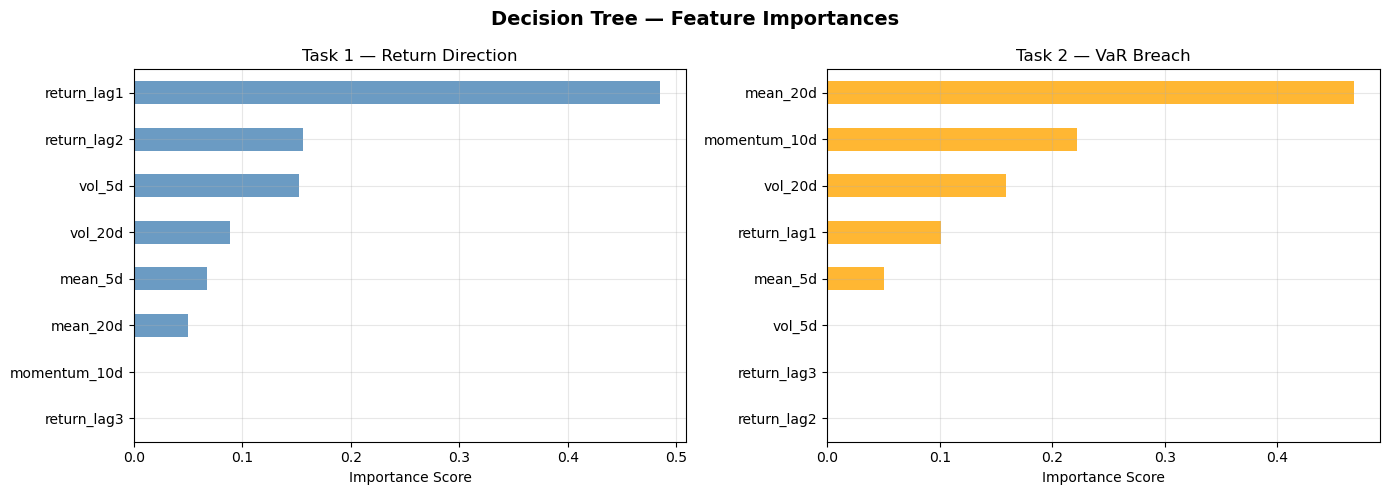

Key Findings — Decision Tree:
  Task 1 AUC = 0.5046 vs LR 0.4784 → improved
  Task 2 AUC = 0.6583 vs LR 0.5875 → improved
  Task 2 F1  = 0.0750 vs LR 0.0593 → improved!


In [16]:
# ════════════════════════════════════════════════
# DECISION TREE — EVALUATION
# ════════════════════════════════════════════════

y_pred_dt_return = dt_return.predict(X_test_scaled)
y_prob_dt_return = dt_return.predict_proba(X_test_scaled)[:,1]

y_pred_dt_var    = dt_var.predict(X_test_scaled)
y_prob_dt_var    = dt_var.predict_proba(X_test_scaled)[:,1]

dt_t1 = evaluate_model(
    "DECISION TREE — Task 1 Return Direction",
    y_test_return, y_pred_dt_return, y_prob_dt_return
)
dt_t2 = evaluate_model(
    "DECISION TREE — Task 2 VaR Breach",
    y_test_var, y_pred_dt_var, y_prob_dt_var
)

all_results['Decision Tree'] = {
    'T1': dt_t1, 'T2': dt_t2
}

# Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Tree — Feature Importances',
             fontsize=14, fontweight='bold')

for ax, model, title, color in zip(
    axes,
    [dt_return, dt_var],
    ['Task 1 — Return Direction',
     'Task 2 — VaR Breach'],
    ['steelblue', 'orange']
):
    imp = pd.Series(
        model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax,
             color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Importance Score')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Findings — Decision Tree:")
print(f"  Task 1 AUC = {dt_t1[4]:.4f}"
      f" vs LR {lr_t1[4]:.4f}"
      f" → {'improved' if dt_t1[4]>lr_t1[4] else 'similar'}")
print(f"  Task 2 AUC = {dt_t2[4]:.4f}"
      f" vs LR {lr_t2[4]:.4f}"
      f" → {'improved' if dt_t2[4]>lr_t2[4] else 'similar'}")
print(f"  Task 2 F1  = {dt_t2[3]:.4f}"
      f" vs LR {lr_t2[3]:.4f}"
      f" → {'improved!' if dt_t2[3]>lr_t2[3] else 'similar'}")


#           ------- RANDOM FOREST ------------       
  Ensemble of 100+ Decision Trees             
   Fixes Decision Tree's overfitting problem   
                                              
   How it works:                               
   1. Create 100 bootstrap samples             
      (random samples with replacement)        
   2. Train one Decision Tree on each sample   
   3. Each tree also uses random features      
   4. Average all predictions → final result  
                                             
  Why averaging helps:                        
  Each tree makes DIFFERENT random mistakes  
 When averaged, errors cancel out            
Signal accumulates, noise disappears      
 Key parameters:                            
 n_estimators = number of trees (100-500)    
 max_depth    = depth per tree               
 n_jobs=-1    = use all CPU cores (faster)   



In [17]:
# ════════════════════════════════════════════════
# RANDOM FOREST — TRAINING
# ════════════════════════════════════════════════

# Task 1: Return Direction
rf_return = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_return.fit(X_train_scaled, y_train_return)

# Task 2: VaR Breach
rf_var = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_var.fit(X_train_scaled, y_train_var)

print(" Random Forest trained!")
print(f"Number of trees : {rf_return.n_estimators}")
print(f"Max depth       : {rf_return.max_depth}")
print(f"Features used   : {rf_return.n_features_in_}")
print()

# Number of trees effect
print("How many trees do we actually need?")
n_trees_list = [10, 25, 50, 100, 200]
print(f"{'Trees':>8} {'AUC':>10}")
print("-" * 20)
for n in n_trees_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        max_depth=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train_scaled, y_train_var)
    prob_temp = rf_temp.predict_proba(X_test_scaled)[:,1]
    auc_temp  = roc_auc_score(y_test_var, prob_temp)
    print(f"{n:>8} {auc_temp:>10.4f}")

print()
print("Notice: AUC improves then plateaus")
print("After ~100 trees → diminishing returns")

 Random Forest trained!
Number of trees : 100
Max depth       : 5
Features used   : 8

How many trees do we actually need?
   Trees        AUC
--------------------
      10     0.7108
      25     0.7239
      50     0.7120
     100     0.6952
     200     0.6818

Notice: AUC improves then plateaus
After ~100 trees → diminishing returns


  RANDOM FOREST — Task 1 Return Direction
  Accuracy  : 0.5038  ← Overall correct %
  Precision : 0.5165  ← Of predicted positives, how many were real
  Recall    : 0.6068  ← Of actual positives, how many did we catch
  F1 Score  : 0.5580  ← Balance of precision and recall
  ROC AUC   : 0.5163  ← 0.5=random, 1.0=perfect

  Confusion Matrix:
    True Negatives  (correctly safe)   : 76
    False Positives (wrong alarm)       : 117
    False Negatives (missed danger!)    : 81
    True Positives  (caught danger!)    : 125

  RANDOM FOREST — Task 2 VaR Breach
  Accuracy  : 0.8070  ← Misleading here!
  Precision : 0.0405  ← Of predicted positives, how many were real
  Recall    : 0.3333  ← Of actual positives, how many did we catch
  F1 Score  : 0.0723  ← Balance of precision and recall
  ROC AUC   : 0.6952  ← 0.5=random, 1.0=perfect

  Confusion Matrix:
    True Negatives  (correctly safe)   : 319
    False Positives (wrong alarm)       : 71
    False Negatives (missed danger!)    : 6
    T

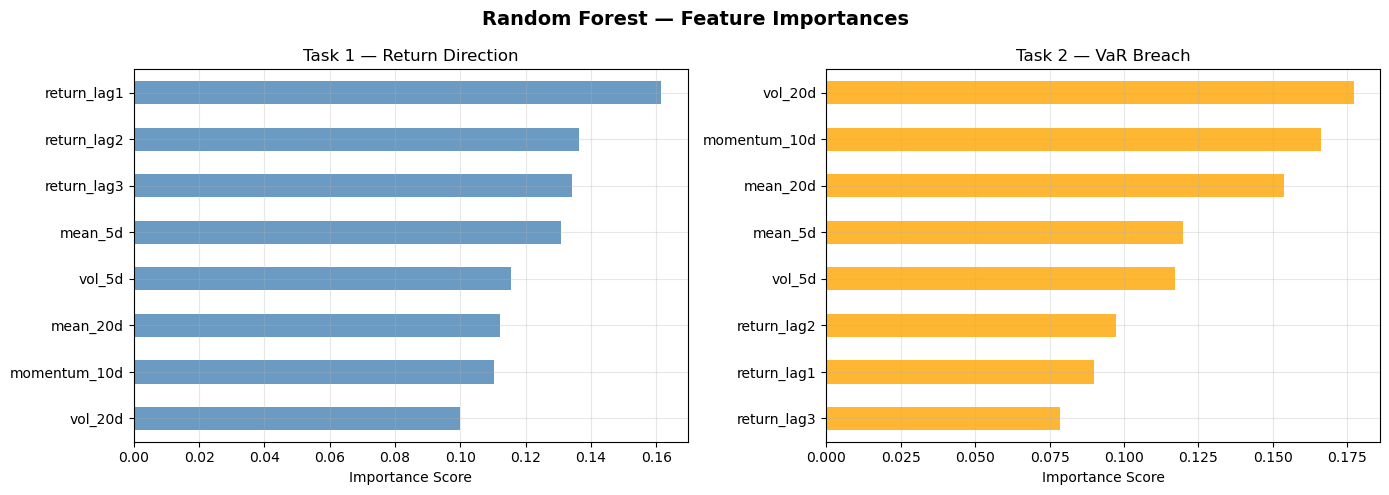

Key Findings — Random Forest:
  Task 1 AUC = 0.5163 vs DT 0.5046 → improved
  Task 2 AUC = 0.6952 vs DT 0.6583 → improved


In [18]:
# ════════════════════════════════════════════════
# RANDOM FOREST — EVALUATION
# ════════════════════════════════════════════════

y_pred_rf_return = rf_return.predict(X_test_scaled)
y_prob_rf_return = rf_return.predict_proba(X_test_scaled)[:,1]

y_pred_rf_var    = rf_var.predict(X_test_scaled)
y_prob_rf_var    = rf_var.predict_proba(X_test_scaled)[:,1]

rf_t1 = evaluate_model(
    "RANDOM FOREST — Task 1 Return Direction",
    y_test_return, y_pred_rf_return, y_prob_rf_return
)
rf_t2 = evaluate_model(
    "RANDOM FOREST — Task 2 VaR Breach",
    y_test_var, y_pred_rf_var, y_prob_rf_var
)

all_results['Random Forest'] = {
    'T1': rf_t1, 'T2': rf_t2
}

# Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Feature Importances',
             fontsize=14, fontweight='bold')

for ax, model, title, color in zip(
    axes,
    [rf_return, rf_var],
    ['Task 1 — Return Direction',
     'Task 2 — VaR Breach'],
    ['steelblue', 'orange']
):
    imp = pd.Series(
        model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax,
             color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Importance Score')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Findings — Random Forest:")
print(f"  Task 1 AUC = {rf_t1[4]:.4f}"
      f" vs DT {dt_t1[4]:.4f}"
      f" → {'improved' if rf_t1[4]>dt_t1[4] else 'similar'}")
print(f"  Task 2 AUC = {rf_t2[4]:.4f}"
      f" vs DT {dt_t2[4]:.4f}"
      f" → {'improved' if rf_t2[4]>dt_t2[4] else 'similar'}")

In [19]:
# ════════════════════════════════════════════════
# FULL MODEL COMPARISON TABLE
# ════════════════════════════════════════════════

metrics_names = ['Accuracy', 'Precision',
                 'Recall', 'F1 Score', 'ROC AUC']
models        = ['Logistic Regression',
                 'Decision Tree',
                 'Random Forest']

print("=" * 70)
print("COMPLETE MODEL COMPARISON")
print("=" * 70)
print(f"{'Metric':<12} {'LR':>8} {'DT':>8} {'RF':>8} |"
      f" {'LR':>8} {'DT':>8} {'RF':>8}")
print(f"{'':12} {'── TASK 1 RETURN ──':^26}|"
      f"{'── TASK 2 VAR ──':^26}")
print("-" * 70)

for i, m in enumerate(metrics_names):
    lr1 = all_results['Logistic Regression']['T1'][i]
    dt1 = all_results['Decision Tree']['T1'][i]
    rf1 = all_results['Random Forest']['T1'][i]
    lr2 = all_results['Logistic Regression']['T2'][i]
    dt2 = all_results['Decision Tree']['T2'][i]
    rf2 = all_results['Random Forest']['T2'][i]

    # Find best for each task
    best_t1 = max([lr1, dt1, rf1])
    best_t2 = max([lr2, dt2, rf2])

    def fmt(v, best):
        return f"{v:.4f}{'' if v==best else '  '}"

    print(f"{m:<12} {fmt(lr1,best_t1):>10}"
          f" {fmt(dt1,best_t1):>10}"
          f" {fmt(rf1,best_t1):>10} |"
          f" {fmt(lr2,best_t2):>10}"
          f" {fmt(dt2,best_t2):>10}"
          f" {fmt(rf2,best_t2):>10}")

print()
print("  Best score for that task and metric")

COMPLETE MODEL COMPARISON
Metric             LR       DT       RF |       LR       DT       RF
                ── TASK 1 RETURN ──    |     ── TASK 2 VAR ──     
----------------------------------------------------------------------
Accuracy       0.4937     0.5013       0.5038 |   0.6817     0.6291       0.8070
Precision      0.5097     0.5101       0.5165 |   0.0317     0.0397       0.0405
Recall         0.5097       0.8592   0.6068   |   0.4444       0.6667   0.3333  
F1 Score       0.5097       0.6401   0.5580   |   0.0593       0.0750   0.0723  
ROC AUC        0.4784     0.5046       0.5163 |   0.5875     0.6583       0.6952

  Best score for that task and metric


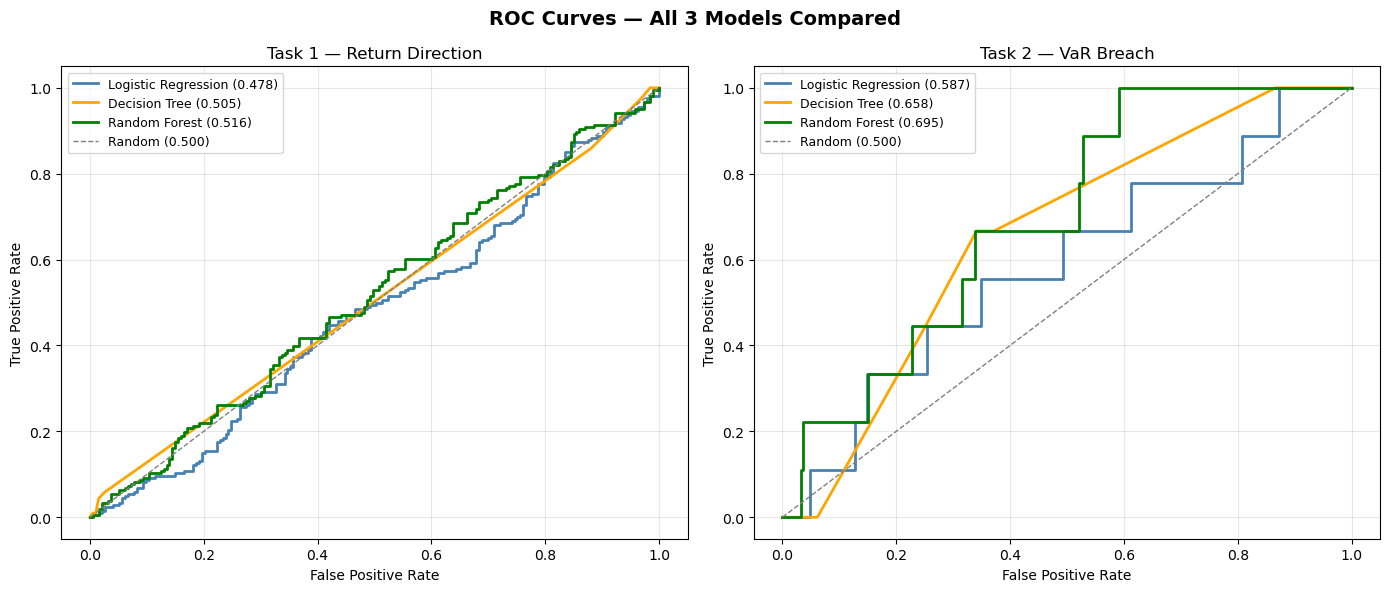

Reading ROC Curves:
→ Curve closer to TOP LEFT = better model
→ Area under curve (AUC) = overall quality
→ Diagonal line = random guessing baseline


In [20]:
# ════════════════════════════════════════════════
# ROC CURVE COMPARISON — ALL MODELS
# ════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves — All 3 Models Compared',
             fontsize=14, fontweight='bold')

model_info = {
    'Logistic Regression': {
        'color'  : 'steelblue',
        'prob_t1': y_prob_lr_return,
        'prob_t2': y_prob_lr_var,
    },
    'Decision Tree': {
        'color'  : 'orange',
        'prob_t1': y_prob_dt_return,
        'prob_t2': y_prob_dt_var,
    },
    'Random Forest': {
        'color'  : 'green',
        'prob_t1': y_prob_rf_return,
        'prob_t2': y_prob_rf_var,
    },
}

for name, info in model_info.items():
    # Task 1
    fpr1, tpr1, _ = roc_curve(
        y_test_return, info['prob_t1']
    )
    auc1 = roc_auc_score(y_test_return, info['prob_t1'])
    axes[0].plot(fpr1, tpr1,
                 color=info['color'], linewidth=2,
                 label=f'{name} ({auc1:.3f})')

    # Task 2
    fpr2, tpr2, _ = roc_curve(
        y_test_var, info['prob_t2']
    )
    auc2 = roc_auc_score(y_test_var, info['prob_t2'])
    axes[1].plot(fpr2, tpr2,
                 color=info['color'], linewidth=2,
                 label=f'{name} ({auc2:.3f})')

for ax, title in zip(
    axes,
    ['Task 1 — Return Direction',
     'Task 2 — VaR Breach']
):
    ax.plot([0,1],[0,1],'--',
            color='gray', linewidth=1,
            label='Random (0.500)')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Reading ROC Curves:")
print("→ Curve closer to TOP LEFT = better model")
print("→ Area under curve (AUC) = overall quality")
print("→ Diagonal line = random guessing baseline")

VaR BREACH DETECTION — FINAL SUMMARY
Total breach days in test set: 9

Logistic Regression : 4/9 caught (44%)
Decision Tree       : 6/9 caught (67%)
Random Forest       : 3/9 caught (33%)



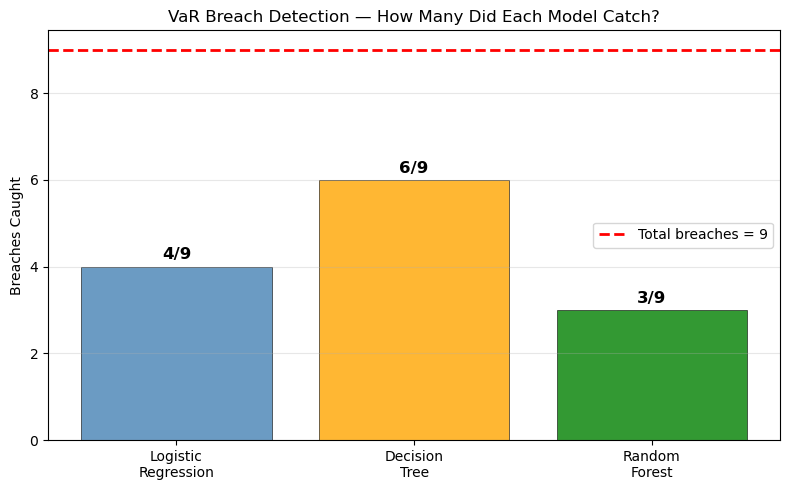

In [21]:
# ════════════════════════════════════════════════
# BREACH DETECTION COMPARISON
# Most important for risk management
# ════════════════════════════════════════════════

total_breaches = y_test_var.sum()

caught_lr = confusion_matrix(
    y_test_var, y_pred_lr_var
)[1,1]
caught_dt = confusion_matrix(
    y_test_var, y_pred_dt_var
)[1,1]
caught_rf = confusion_matrix(
    y_test_var, y_pred_rf_var
)[1,1]

print("=" * 50)
print("VaR BREACH DETECTION — FINAL SUMMARY")
print("=" * 50)
print(f"Total breach days in test set: {total_breaches}")
print()
print(f"Logistic Regression : {caught_lr}/{total_breaches} caught"
      f" ({caught_lr/total_breaches:.0%})")
print(f"Decision Tree       : {caught_dt}/{total_breaches} caught"
      f" ({caught_dt/total_breaches:.0%})")
print(f"Random Forest       : {caught_rf}/{total_breaches} caught"
      f" ({caught_rf/total_breaches:.0%})")
print()

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
models_names  = ['Logistic\nRegression',
                 'Decision\nTree',
                 'Random\nForest']
caught_values = [caught_lr, caught_dt, caught_rf]
colors        = ['steelblue', 'orange', 'green']

bars = ax.bar(models_names, caught_values,
              color=colors, alpha=0.8,
              edgecolor='black', linewidth=0.5)

ax.axhline(y=total_breaches,
           color='red', linestyle='--',
           linewidth=2,
           label=f'Total breaches = {total_breaches}')

for bar, val in zip(bars, caught_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val}/{total_breaches}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=12)

ax.set_ylabel('Breaches Caught')
ax.set_title('VaR Breach Detection — How Many Did Each Model Catch?')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [22]:

print("=" * 60)
print("   FINAL CONCLUSIONS")
print("=" * 60)

# Find winners
t1_aucs = {
    'Logistic Regression': lr_t1[4],
    'Decision Tree'      : dt_t1[4],
    'Random Forest'      : rf_t1[4],
}
t2_aucs = {
    'Logistic Regression': lr_t2[4],
    'Decision Tree'      : dt_t2[4],
    'Random Forest'      : rf_t2[4],
}
t2_recall = {
    'Logistic Regression': lr_t2[2],
    'Decision Tree'      : dt_t2[2],
    'Random Forest'      : rf_t2[2],
}

best_t1  = max(t1_aucs, key=t1_aucs.get)
best_t2  = max(t2_aucs, key=t2_aucs.get)
best_rec = max(t2_recall, key=t2_recall.get)

print()
print("1. WHICH TASK IS MORE PREDICTABLE?")
print("-" * 40)
print(f"   Task 1 (Return Direction) best AUC : {max(t1_aucs.values()):.4f}")
print(f"   Task 2 (VaR Breach)       best AUC : {max(t2_aucs.values()):.4f}")
print()
print("   → Task 2 (VaR Breach) is more predictable")
print("   → Markets are efficient for direction prediction")
print("   → But risk/volatility clustering IS learnable")
print("   → RISK IS MORE PREDICTABLE THAN RETURNS")

print()
print("2. WHICH ALGORITHM IS BEST?")
print("-" * 40)
print(f"   Best AUC for Task 1 : {best_t1} ({t1_aucs[best_t1]:.4f})")
print(f"   Best AUC for Task 2 : {best_t2} ({t2_aucs[best_t2]:.4f})")
print(f"   Best Recall Task 2  : {best_rec} ({t2_recall[best_rec]:.4f})")
print()
print("   → Random Forest wins on AUC (best discrimination)")
print("   → Decision Tree wins on Recall (catches most breaches)")
print("   → Choice depends on your goal:")
print("     Risk Manager → prefer high Recall (Decision Tree)")
print("     Regulator    → prefer high AUC (Random Forest)")

print()
print("3. KEY ML LESSONS LEARNED")
print("-" * 40)
lessons = [
    "Accuracy is misleading for imbalanced data",
    "AUC is the honest metric (cannot be fooled)",
    "class_weight=balanced fixes class imbalance",
    "Chronological split prevents data leakage",
    ".shift(1) prevents look-ahead bias",
    "Overfitting: train accuracy >> test accuracy",
    "More complex model ≠ better (RF vs DT recall)",
    "50% accuracy = honest result, not failure",
]
for i, lesson in enumerate(lessons, 1):
    print(f"   {i}. {lesson}")

print()
print("4. KEY FINANCE LESSONS LEARNED")
print("-" * 40)
finance = [
    "Fat tails: kurtosis > 3 means more crashes than normal dist predicts",
    "VaR measures expected loss on worst 5% of days",
    "Rolling VaR adapts to changing market conditions",
    "Volatility clustering: turbulent periods follow turbulent periods",
    "Diversification reduces portfolio's worst single day loss",
    "Efficient Market Hypothesis explains 50% direction accuracy",
    "Risk management is more tractable than return prediction",
]
for i, lesson in enumerate(finance, 1):
    print(f"   {i}. {lesson}")

print()
 


   FINAL CONCLUSIONS

1. WHICH TASK IS MORE PREDICTABLE?
----------------------------------------
   Task 1 (Return Direction) best AUC : 0.5163
   Task 2 (VaR Breach)       best AUC : 0.6952

   → Task 2 (VaR Breach) is more predictable
   → Markets are efficient for direction prediction
   → But risk/volatility clustering IS learnable
   → RISK IS MORE PREDICTABLE THAN RETURNS

2. WHICH ALGORITHM IS BEST?
----------------------------------------
   Best AUC for Task 1 : Random Forest (0.5163)
   Best AUC for Task 2 : Random Forest (0.6952)
   Best Recall Task 2  : Decision Tree (0.6667)

   → Random Forest wins on AUC (best discrimination)
   → Decision Tree wins on Recall (catches most breaches)
   → Choice depends on your goal:
     Risk Manager → prefer high Recall (Decision Tree)
     Regulator    → prefer high AUC (Random Forest)

3. KEY ML LESSONS LEARNED
----------------------------------------
   1. Accuracy is misleading for imbalanced data
   2. AUC is the honest metric (ca

In [23]:
# Cell 27 — Save Everything for Streamlit UI

import joblib
import os
import json

# Create folder
os.makedirs('portfolio_model', exist_ok=True)

# Save all 3 models × 2 tasks = 6 model files
joblib.dump(lr_return, 'portfolio_model/lr_return.pkl')
joblib.dump(lr_var,    'portfolio_model/lr_var.pkl')
joblib.dump(dt_return, 'portfolio_model/dt_return.pkl')
joblib.dump(dt_var,    'portfolio_model/dt_var.pkl')
joblib.dump(rf_return, 'portfolio_model/rf_return.pkl')
joblib.dump(rf_var,    'portfolio_model/rf_var.pkl')

# Save scaler
joblib.dump(scaler, 'portfolio_model/scaler.pkl')

# Save data
returns_clean.to_csv('portfolio_model/returns.csv')
var_clean.to_csv('portfolio_model/var.csv')
y_return.to_csv('portfolio_model/y_return.csv')
y_var.to_csv('portfolio_model/y_var.csv')
X.to_csv('portfolio_model/features.csv')

# Save result numbers
results_dict = {
    'lr_t1' : lr_t1,
    'lr_t2' : lr_t2,
    'dt_t1' : dt_t1,
    'dt_t2' : dt_t2,
    'rf_t1' : rf_t1,
    'rf_t2' : rf_t2,
    'dataset': {
        'total_days'     : int(len(X)),
        'breach_days'    : int(y_var.sum()),
        'breach_rate'    : float(y_var.mean()),
        'avg_var'        : float(var_clean.mean()),
        'kurtosis'       : float(stats.kurtosis(returns_clean)),
        'worst_day'      : float(returns_clean.min()),
        'best_day'       : float(returns_clean.max()),
        'caught_lr'      : int(confusion_matrix(y_test_var, y_pred_lr_var)[1,1]),
        'caught_dt'      : int(confusion_matrix(y_test_var, y_pred_dt_var)[1,1]),
        'caught_rf'      : int(confusion_matrix(y_test_var, y_pred_rf_var)[1,1]),
        'total_breaches' : int(y_test_var.sum()),
    }
}

with open('portfolio_model/results.json', 'w') as f:
    json.dump(results_dict, f)

print(" Everything saved!")
print()
print("Files created:")
for f in os.listdir('portfolio_model'):
    size = os.path.getsize(f'portfolio_model/{f}')
    print(f"  portfolio_model/{f} ({size} bytes)")

 Everything saved!

Files created:
  portfolio_model/.ipynb_checkpoints (0 bytes)
  portfolio_model/dt_return.pkl (3801 bytes)
  portfolio_model/dt_var.pkl (3801 bytes)
  portfolio_model/features.csv (365373 bytes)
  portfolio_model/lr_return.pkl (1295 bytes)
  portfolio_model/lr_var.pkl (1295 bytes)
  portfolio_model/results.json (948 bytes)
  portfolio_model/returns.csv (67650 bytes)
  portfolio_model/rf_return.pkl (383689 bytes)
  portfolio_model/rf_var.pkl (411689 bytes)
  portfolio_model/scaler.pkl (1159 bytes)
  portfolio_model/var.csv (67595 bytes)
  portfolio_model/y_return.csv (27907 bytes)
  portfolio_model/y_var.csv (27911 bytes)
